<a href="https://colab.research.google.com/github/Aditya00-77/COVID_19/blob/master/walmart_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#a)PROBLEM STATEMENTS: The goal is to forecast walmart weekly sales using the historical store date,holiday,and economic indicators so the business can be better mactch ventory with demand

#b) Project Objective
#The objective is to analyze historical sales data and build a prediction model to forecast sales for future weeks, helping with demand planning and inventory decisions.

#c)Data Description
#The dataset contains 6,435 rows and 8 columns: Store, Date, WeeklySales, HolidayFlag, Temperature, FuelPrice, CPI, and Unemployment.

#This matches the standard Walmart forecasting dataset schema used for retail sales prediction.

#d) Data Pre-processing Steps and Inspiration
#The notebook converts the Date column to datetime, coerces numeric columns to numeric types, checks nulls and duplicates, and removes rows with missing dates.

#The project also uses median/mode-based filling logic in case missing values appear, which is a practical retail forecasting preprocessing approach.

#e)Choosing the Algorithm for the Project
#The model used in the notebook is RandomForestRegressor, trained with time-based features and economic variables.

#Motivation and Reasons For Choosing the Algorithm
#Random Forest is a good fit because it handles nonlinear relationships, mixed feature types, and interactions between sales drivers without requiring heavy scaling or complex feature engineering.

#It also performs well as a strong baseline for tabular forecasting problems like this one.

#Assumptions
#The project assumes that historical relationships between sales and factors such as holidays, temperature, fuel price, CPI, and unemployment remain useful for near-future forecasting.
#It also assumes that weekly patterns and store-specific behavior are stable enough for the model to learn from past data.

#Model Evaluation and Techniques
#The notebook uses a time-based train/test split, trains RandomForestRegressor, and evaluates with RMSE and MAE.

#Reported results are RMSE 112,337.67 and MAE 60,051.75

#Inferences from the Same
#Holiday weeks have higher average weekly sales than non-holiday weeks in the notebook analysis.

#The notebook also shows clear variation across stores and different sensitivity to variables like unemployment, temperature, and CPI, which suggests store-level behavior matters

#Future Possibilities of the Project
#Future improvements could include feature engineering from date components, lag features, rolling averages, store-wise models, and hyperparameter tuning.

#A stronger forecasting setup could also compare Random Forest with gradient boosting and time-series-specific models

#Model saving
#For submission, save the trained model after fitting. For a scikit-learn model, joblib.dump() is the recommended approach for persisting fitted estimators to disk.

#Use a file name like walmart_random_forest_model.joblib, and include that file with your submission

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import pearsonr
from sklearn.linear_model  import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error


In [ ]:
df = pd.read_csv("/content/Walmart DataSet.csv")
df.head(2)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106


In [ ]:
df.info() # so basically their are no null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head(2)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106


In [ ]:
df['Date'] = pd.to_datetime(df['Date'],errors='coerce',dayfirst=True) # convertingthe date format
for col in ['Store','Weekly_Sales','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment']:
  df[col] = pd.to_numeric(df[col],errors='coerce')


In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
# IF THEIR ARE ANY NULL VALUES SO IT WILL BE FILLED WITH THE HELP OF THIS
df['Weekly_Sales'] = df['Weekly_Sales'].fillna(df['Weekly_Sales'].median())
df['Temperature'] = df['Temperature'].fillna(df['Temperature'].median())
df['Fuel_Price'] = df['Fuel_Price'].fillna(df['Fuel_Price'].median())
df['CPI'] = df['CPI'].fillna(df['CPI'].median())
df['Unemployment'] =df['Unemployment'].fillna(df['Unemployment'].median())
df['Holiday_Flag'] = df['Holiday_Flag'].fillna(0)
df['Store'] = df['Store'].fillna(df['Store'].mode()[0]) # first mode value becuase thier can be mutli mode


In [ ]:
# removing rows where the date is missing :
df = df.dropna(subset=['Date'])

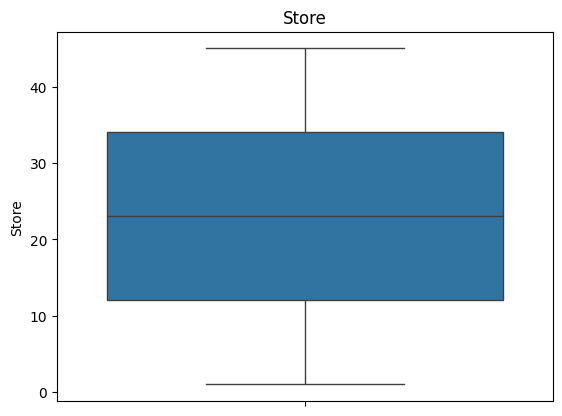

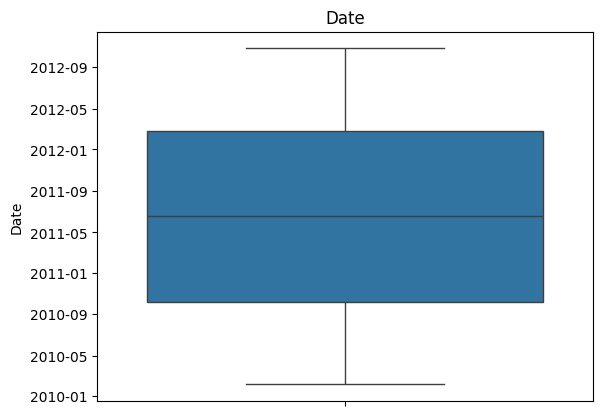

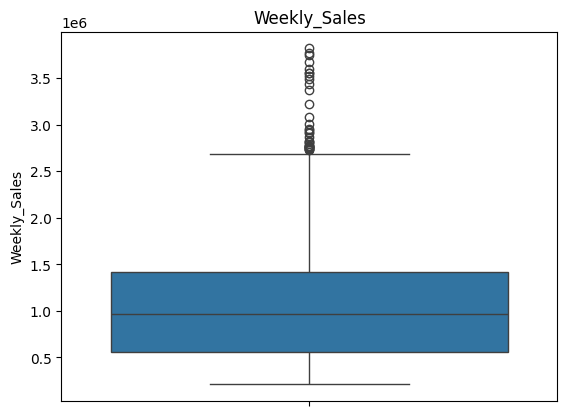

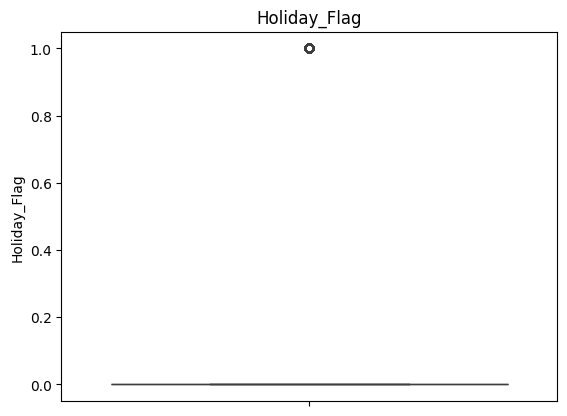

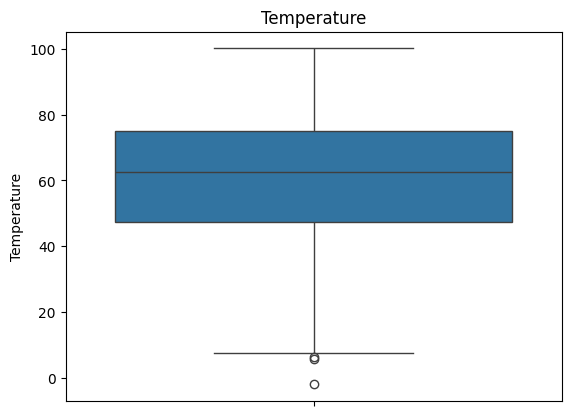

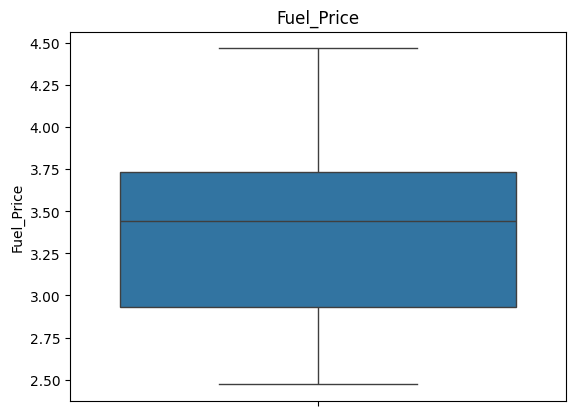

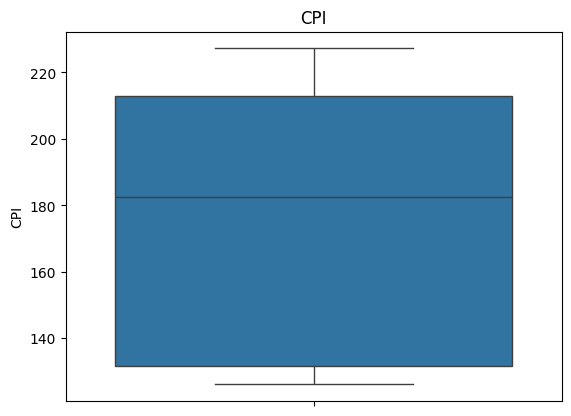

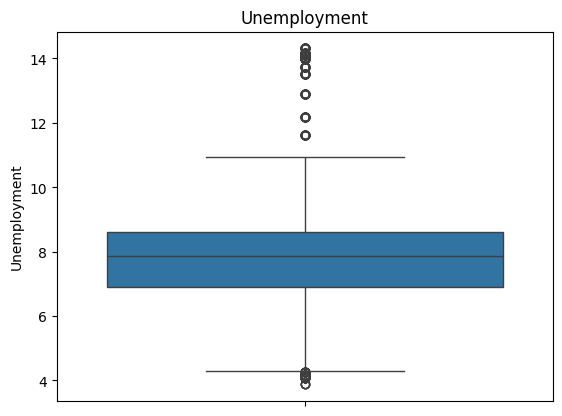

In [ ]:
for x in df.columns:
  if df[x].dtype!='object':
    sns.boxplot(df[x])
    plt.title(x)
    plt.show()

In [ ]:
def find_outliers(column):
  q1 = df[column].quantile(0.25)
  q3 = df[column].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr
  return df[(df[column]<lower) & (df[column]>upper)]

In [ ]:
print("\nOutliers in weekly_sales:",len(find_outliers("Weekly_Sales")))
print("\nOutliers in temperature:",len(find_outliers("Temperature")))
print("\nOutliers in CPI:",len(find_outliers("CPI")))
print("\nOutliers in Unemployment:",len(find_outliers("Unemployment")))




Outliers in weekly_sales: 0

Outliers in temperature: 0

Outliers in CPI: 0

Outliers in Unemployment: 0


In [ ]:
# date features
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week.astype(int)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   year          6435 non-null   int32         
 9   month         6435 non-null   int32         
 10  week          6435 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int32(2), int64(3)
memory usage: 502.9 KB


In [ ]:
# store wise average sales
store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
store_sales.head() # top 5 weekly sales

,Weekly_Sales
Store,
20,2.107677e+06
4,2.094713e+06
14,2.020978e+06
13,2.003620e+06
2,1.925751e+06


In [ ]:
highest_store = store_sales.idxmax() # which store is having the highest weekly_sales is 20
lowest_store = store_sales.idxmin() # which store is having the lowest weekly_sales
highst_sales = store_sales.max() # maximum weekly sales values
lowest_sales = store_sales.min() # minimum weekly sales are this


In [ ]:
print("\nHighest performing store:",highest_store, '->', highst_sales)
print("Worst performing store:",lowest_store,'-->',lowest_sales)
print('difference',highst_sales - lowest_sales)


Highest performing store: 20 -> 2107676.8703496503
Worst performing store: 33 --> 259861.69202797202
difference 1847815.1783216782


In [ ]:
# correlation with weekly sales
corr_columns = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment','Holiday_Flag']
corr = df[corr_columns].corr()
print('\nCorrelation matrix:')
print(corr)


Correlation matrix:
              Weekly_Sales  Temperature  Fuel_Price       CPI  Unemployment  \
Weekly_Sales      1.000000    -0.063810    0.009464 -0.072634     -0.106176   
Temperature      -0.063810     1.000000    0.144982  0.176888      0.101158   
Fuel_Price        0.009464     0.144982    1.000000 -0.170642     -0.034684   
CPI              -0.072634     0.176888   -0.170642  1.000000     -0.302020   
Unemployment     -0.106176     0.101158   -0.034684 -0.302020      1.000000   
Holiday_Flag      0.036891    -0.155091   -0.078347 -0.002162      0.010960   

              Holiday_Flag  
Weekly_Sales      0.036891  
Temperature      -0.155091  
Fuel_Price       -0.078347  
CPI              -0.002162  
Unemployment      0.010960  
Holiday_Flag      1.000000  


In [ ]:
print("\nCorrelation with Weekly_Sales:")
print(corr['Weekly_Sales'].sort_values(ascending=False))



Correlation with Weekly_Sales:
Weekly_Sales    1.000000
Holiday_Flag    0.036891
Fuel_Price      0.009464
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Name: Weekly_Sales, dtype: float64


In [ ]:
# store wise unemployement effect
store_umemp_corr = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['Unemployment']))
store_umemp_corr = store_umemp_corr.sort_values()
print("\nStores most affected by unemployement factor:")
print(store_umemp_corr.head(10))


Stores most affected by unemployement factor:
Store
38   -0.785290
44   -0.780076
39   -0.384681
42   -0.356355
41   -0.350630
4    -0.337015
17   -0.263600
3    -0.230413
37   -0.221287
5    -0.207043
dtype: float64


In [ ]:
store_temp_corr = df.groupby('Store').apply(lambda x:x['Weekly_Sales'].corr(x['Temperature']))
store_temp_corr = store_temp_corr.sort_values()
print("\nStores most affected by temperature:")
print(store_temp_corr.head(10))


Stores most affected by temperature:
Store
10   -0.432569
12   -0.379416
3    -0.377524
28   -0.376506
30   -0.330816
8    -0.312324
37   -0.300493
2    -0.297673
34   -0.278523
11   -0.278503
dtype: float64


In [ ]:
store_cpi_corr = df.groupby('Store').apply(lambda x:x['Weekly_Sales'].corr(x['CPI']))
store_cpi_corr = store_cpi_corr.sort_values()
print('\nStores most affected by CPI:')
print(store_cpi_corr.head(10))


Stores most affected by CPI:
Store
36   -0.915095
35   -0.424107
14   -0.419755
30   -0.298188
43   -0.285686
27   -0.213082
18   -0.193541
15   -0.174467
21   -0.163649
19   -0.155341
dtype: float64


In [ ]:
# Seasonal trend:
monthly_sales = df.groupby('month')['Weekly_Sales'].mean()
print("\nAverage sales by month:")
print(monthly_sales)


Average sales by month:
month
1     9.238846e+05
2     1.053200e+06
3     1.013309e+06
4     1.026762e+06
5     1.031714e+06
6     1.064325e+06
7     1.031748e+06
8     1.048017e+06
9     9.893353e+05
10    9.996321e+05
11    1.147266e+06
12    1.281864e+06
Name: Weekly_Sales, dtype: float64


In [ ]:
# quarter sales
quartely_sales = df.groupby(df['Date'].dt.quarter)['Weekly_Sales'].mean()
print("\nAverage sales by quarter:")
print(quartely_sales)


Average sales by quarter:
Date
1    1.006136e+06
2    1.040806e+06
3    1.023251e+06
4    1.128774e+06
Name: Weekly_Sales, dtype: float64


In [ ]:
# holiday impact
holiday_avg = df[df['Holiday_Flag']==1]['Weekly_Sales'].mean()
non_holiday_avg = df[df['Holiday_Flag']==0]['Weekly_Sales'].mean()
print('\nAverage holiday sales:',holiday_avg)
print('\nAverage non-holiday sales:',non_holiday_avg)


Average holiday sales: 1122887.8923555557

Average non-holiday sales: 1041256.3802088555


<function matplotlib.pyplot.show(close=None, block=None)>

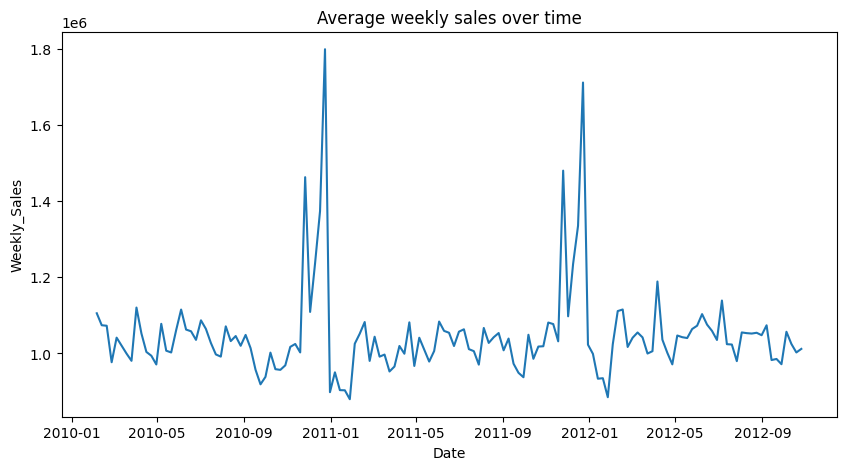

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df.groupby('Date')['Weekly_Sales'].mean().reset_index(),x='Date',y='Weekly_Sales')
plt.title("Average weekly sales over time")
plt.show

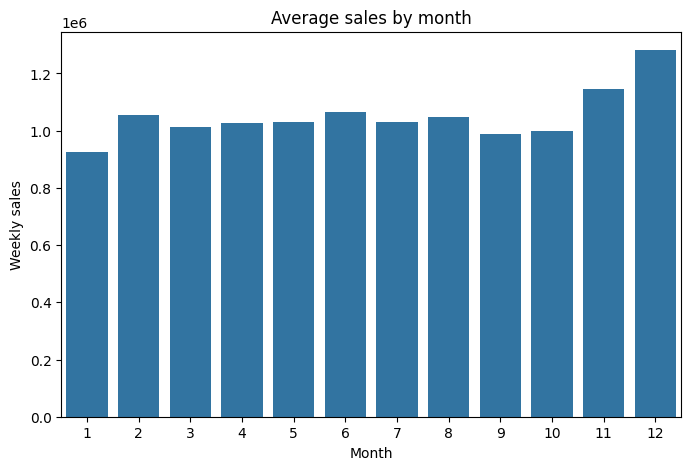

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=monthly_sales.index,y=monthly_sales.values)
plt.title("Average sales by month")
plt.xlabel("Month")
plt.ylabel("Weekly sales")
plt.show()

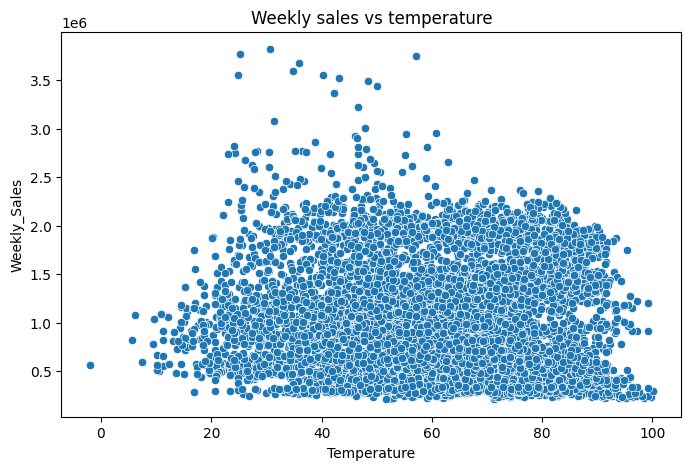

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='Temperature',y='Weekly_Sales')
plt.title("Weekly sales vs temperature")
plt.show()

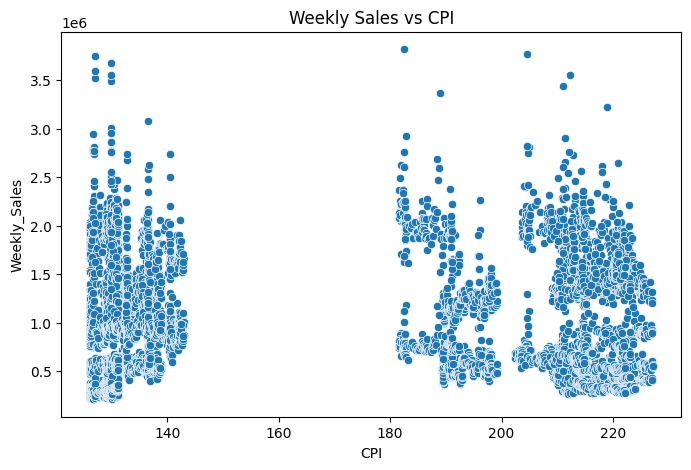

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='CPI',y='Weekly_Sales')
plt.title("Weekly Sales vs CPI")
plt.show()

#Forecasting model

In [ ]:
# use simple time features + store + economic variables
features = ['Store','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment','year','month','week']
target = 'Weekly_Sales'

In [ ]:
df = df.sort_values("Date")
cutoff = df['Date'].max() - pd.Timedelta(weeks=12)

In [ ]:
train = df[df['Date']<=cutoff]
test = df[df['Date']>cutoff]

In [ ]:
X_train =train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

In [ ]:
model = RandomForestRegressor(n_estimators=200,random_state=42)
model.fit(X_train,y_train)
pred = model.predict(X_test)

In [ ]:
rmse  = np.sqrt(mean_squared_error(y_test,pred))
mae = mean_absolute_error(y_test,pred)

In [ ]:
print('\nForecast model results:')
print('RMSE',rmse)
print('mae',mae)


Forecast model results:
RMSE 112337.67330095902
mae 60051.7480603704


In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

last_date = df["Date"].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=12, freq="W-SAT")

future_rows = []

for store in df["Store"].dropna().unique():
    store_df = df[df["Store"] == store]

    temp = store_df["Temperature"].tail(4).mean()
    fuel = store_df["Fuel_Price"].tail(4).mean()
    cpi = store_df["CPI"].tail(4).mean()
    unemp = store_df["Unemployment"].tail(4).mean()

    temp = temp if pd.notna(temp) else df["Temperature"].median()
    fuel = fuel if pd.notna(fuel) else df["Fuel_Price"].median()
    cpi = cpi if pd.notna(cpi) else df["CPI"].median()
    unemp = unemp if pd.notna(unemp) else df["Unemployment"].median()

    for d in future_dates:
        future_rows.append({
            "Store": store,
            "Holiday_Flag": 0,
            "Temperature": temp,
            "Fuel_Price": fuel,
            "CPI": cpi,
            "Unemployment": unemp,
            "Year": d.year,
            "Month": d.month,
            "Week": int(d.isocalendar().week)
        })

future_df = pd.DataFrame(future_rows)

future_df = df[features]
print(future_df.isna().sum())

future_df["Predicted_Weekly_Sales"] = model.predict(future_df)
print(future_df.head(20))

Store           0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
year            0
month           0
week            0
dtype: int64
      Store  Holiday_Flag  Temperature  Fuel_Price         CPI  Unemployment  \
0         1             0        42.31       2.572  211.096358         8.106   
1287     10             0        54.34       2.962  126.442065         9.765   
5148     37             0        45.97       2.572  209.852966         8.554   
2288     17             0        23.11       2.666  126.442065         6.548   
4147     30             0        39.05       2.572  210.752605         8.324   
3432     25             0        21.10       2.784  204.247194         8.187   
3003     22             0        24.36       2.788  135.352461         8.283   
3146     23             0        15.25       2.788  131.527903         5.892   
3289     24             0        22.43       2.954  131.527903         8.326   
2574     19             0

In [ ]:
store_sales.to_csv("top_store_sales.csv")
future_df.to_csv("forecast_12_weeks.csv",index=False)